In [1]:
using Distributed

if nprocs() == 1
    addprocs(12)
end

@everywhere using LatticeDecoder

@everywhere function random_bitstring!(b::Vector{Int64}, n)
    @inbounds for i = 1:n
        b[i] = rand(0:1)
    end
end


@everywhere function random_encoding_experiment(H, G, σ, max_iter, samples, local_search = false)
    n = size(H, 1)
    b = zeros(Int64, n)
    tg = initialize_tanner_graph(H)
    decoder = LDLCDecoder(tg; schedule=:parallel, algorithm="lsd", sigma=σ, max_iterations=max_iter)
    lsd = LocalSearch(10, G, [2, 1, 1], false, true, false)
    errors = @distributed (+) for _ = 1:samples
        random_bitstring!(b, n)
        y = encode(b, G)
        y .+= sample_error(σ, n)
        bp_result = run_decoder!(decoder, y)
        
        dec = hard_decision(bp_result, H)
        
        if local_search
            λ = abs.(H * bp_result) .% 1.0
            local_search!(y, λ, dec, lsd) # modifies dec
        end
        
        count_symbol_errors(dec, b)
    end
    return errors / samples / n
end

"""
    agresti_coull_confidence_interval(p, n, z=1.96)

Compute the Agresti-Coull confidence interval for a binomial distribution.
The default value of z is for a 95% confidence interval.
To get the 99% confidence interval, use z=2.576.
To get the 99.9% confidence interval, use z=3.291.
"""
function agresti_coull_confidence_interval(p, n, z=1.96)
    n_tilde = n + z^2
    p_tilde = (p * n + z^2 / 2) / n_tilde
    return z * sqrt(p_tilde * (1 - p_tilde) / n_tilde)
end


agresti_coull_confidence_interval

Running experiment for n = 128, d = 5
Running experiment for n = 256, d = 5
Running experiment for n = 512, d = 5


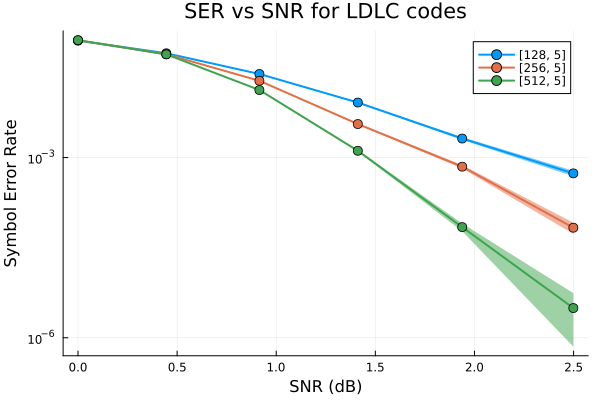

In [4]:

using Plots

samples = 5000;
max_iter = 25;
σ_capacity = lattice_capacity_std();
sigmas = range(σ_capacity, 0.75 * σ_capacity, 6);

d = 5;
ns = [128, 256, 512];

p = plot(
    title="SER vs SNR for LDLC codes",
    xlabel="SNR (dB)",
    ylabel="Symbol Error Rate",
    yscale=:log10,
    legend=:topright,
)
for n in ns
    H = classical_ldlc(d, n, true)
    G = generator_matrix(H)
    println("Running experiment for n = $n, d = $d")
    ber = [random_encoding_experiment(H, G, σ, max_iter, samples) for σ in sigmas]
    ribbon = agresti_coull_confidence_interval.(ber, samples * n)
    plot!(
        p,
        snr_db.(sigmas),
        ber;
        label="[$(n), $(d)]",
        lw=2,
        marker=:circle,
        markersize=5,
        ribbon=ribbon,
    )
end

display(p)


In [8]:

using Plots

samples = 5000;
max_iter = 25;
σ_capacity = lattice_capacity_std();
sigmas = range(σ_capacity, 0.8 * σ_capacity, 6);

d = 5;
ns = [128, 256, 512];

p = plot(
    title="SER vs SNR for LDLC codes",
    xlabel="SNR (dB)",
    ylabel="Symbol Error Rate",
    yscale=:log10,
    legend=:topright,
)
for n in ns
    H = classical_ldlc(d, n, true)
    G = generator_matrix(H)
    println("Running experiment for n = $n, d = $d")
    ber = [random_encoding_experiment(H, G, σ, max_iter, samples) for σ in sigmas]
    println("BER for n = $n, d = $d: ", ber)
    ribbon = agresti_coull_confidence_interval.(ber, samples * n)
    plot!(
        p,
        snr_db.(sigmas),
        ber;
        label="[$(n), $(d)]",
        lw=2,
        marker=:circle,
        markersize=5,
        ribbon=ribbon,
    )
end

display(p)


Running experiment for n = 128, d = 5
BER for n = 128, d = 5: [0.1012296875, 0.0693984375, 0.0409859375, 0.0187109375, 0.008125, 0.0031515625]
Running experiment for n = 256, d = 5
BER for n = 256, d = 5: [0.09480078125, 0.0618, 0.03010546875, 0.01045625, 0.00282265625, 0.000625]
Running experiment for n = 512, d = 5
BER for n = 512, d = 5: [0.094963671875, 0.06152890625, 0.02540078125, 0.005486328125, 0.000758203125, 7.1875e-5]
